# Generate an ATM Pulse and the Detuning Response

## Imports

In [1]:
from PulseDesigner.qipATM import ATMGate, ATMDetuneResponse

import numpy as np
import matplotlib.pyplot as plt

ModuleNotFoundError: No module named 'scipy'

## Pulse Parameters

Change the parameters in the cell below this to modify the ATM Pulse.

A breif overview of the pulse parameters is:

pulseTime -> Set depending mostly on how long you want the pulse to take. A longer pulse time will get better sensivity but settings it too long could cause there to be too much noise during the pulse and thus cause distortion. (Distortion will not be visible in the simulation so as a general rule of thumb stay below T2 Rabi time)

riseTime -> Should probably be about 15% of the total pulse time

fallTime -> Should probably be about 70% of total pulse time (You could make this 80% and then make rise time 10% as well)

maxAmplitude -> Should definitely be set to 2 times the measured Rabi Frequency (Factor of 2 is because it is lab frame). This value will only change the simulation and not the waveform data that is saved. The waveform data is normalized to have a maximum of 1 so that when played through a qua config it will use the same microwave power that you used to measure the rabi frequency.

maxFrequency -> This should be set to the detuning range you want (so if you want the pulse to detect a detuning range of 2MHz then this can be set to 2MHz) (Warning that setting this too high can cause the simulation to take quite a while to run)

riseGradient -> Can probably just be left at 0.95

fallGradient -> This can be played around with to get better sensitivities. Smaller is better but only up to a point. The longer the fall time of the pulse the smaller this gradient can be set.

In [ ]:
# Pulse Parameters
pulseTime = 100  # (us) Total time of the pulse
riseTime = 10  # (us) Amount of time the pulse takes to rise to the maximum amplitude
fallTime = 80  # (us) Amount of time the pulse takes to fall to 0 amplitude
maxAmplitude = 0.6  # (MHZ) Maximum amplitude the pulse will rise too (This should usually be the rabi frequency)
maxFrequency = 0.5 # (MHz) Maximum frequency offset the pulse will start at
percentRiseGradient = 0.2# 0.95 # Inital slope of the rising amplitude of the pulse
percentFallGradient = 0.02 # Ending slope of the falling amplitude

Run this cell to generate and see the ATM Pulse defined by the above parameters

0.00030000000000000003
0.015588457268119896


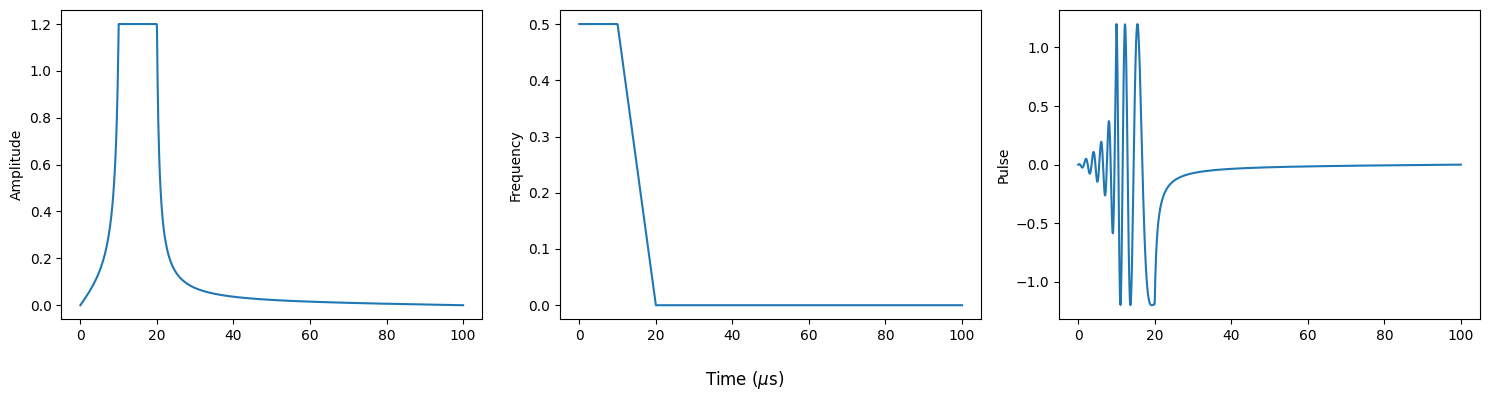

In [ ]:
# Convert rise and fall gradient to absolute instead of relative values
riseGradient = maxAmplitude * percentRiseGradient / riseTime
fallGradient = maxAmplitude * percentFallGradient / fallTime

# Multiplying this by 2 because the amplitude is taken as the lab frame amplitude but our experimental setups give rotating frame
maxAmplitude = maxAmplitude * 2

testGate = ATMGate(pulseTime,
                   riseTime,
                   fallTime,
                   maxAmplitude,
                   maxFrequency,
                   riseGradient,
                   fallGradient)

testGate.plotPulses(orientation="h")

## Detuning Response

Running the next 3 cells will test the pulse at different detunings to find the flip probability as a function of detuning

In [ ]:
testResponse = ATMDetuneResponse()  
testResponse.setATM(testGate)

In [ ]:
testDets = np.concat([np.linspace(-0.8, -0.1, 100), np.linspace(-0.1, 0.1, 100), np.linspace(0.1, 0.8, 100)])

testResponse.testDetuning(resolution=1000, detuning=testDets.tolist())
testResponse.updateCharacteristics()

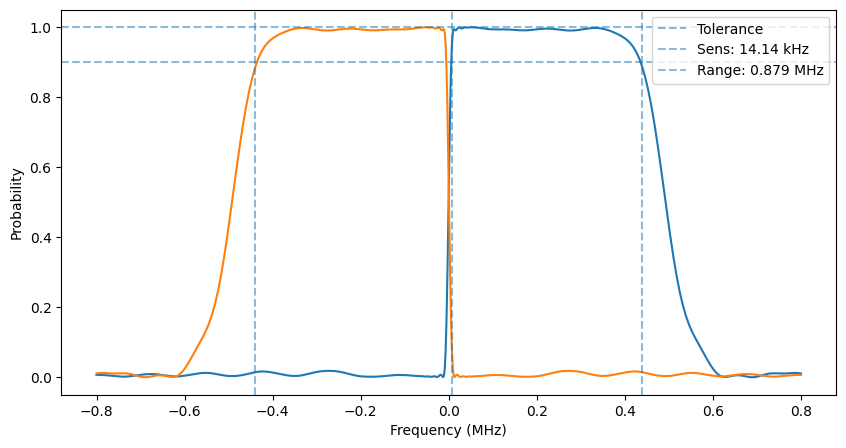

In [ ]:
fig, ax = plt.subplots(1 ,1, figsize=(10, 5))
testResponse.plotReponse(ax)
plt.show()

## Save pulse data

The cells below will save the pulse that was generated above. set the file name to save as in the cell below. (No need to include an extension)

In [ ]:
filename = "test"

In [ ]:
def fourFiles(
    pulseData: tuple[tuple[list[float], list[float]], tuple[list[float], list[float]]],
    fileLoc: str,
    fileName: str
) -> None:

    for i, side in enumerate(["_left_", "_right_"]):
        for j, iq, in enumerate(["I", "Q"]):
            with open(fileLoc[:-4-len(fileName)] + 
                        fileName + 
                        side + 
                        iq + ".txt", "w") as f:
                for pulseValue in pulseData[i][j]:
                    f.write("{:f}".format(float(np.float16(pulseValue))) + "\n")
    
    with open(fileLoc[:-4-len(fileName)] + 
                fileName + "_params.txt", "w") as f:
        f.write("Pulse Time: {}\n".format(pulseTime))
        f.write("Rise Time: {}\n".format(riseTime))
        f.write("Fall Time: {}\n".format(fallTime))
        f.write("Max Amplitude: {}\n".format(maxAmplitude))
        f.write("Max Frequency: {}\n".format(maxFrequency))
        f.write("Percent Rise Gradient: {}\n".format(percentRiseGradient))
        f.write("Percent Gradient: {}\n".format(percentFallGradient))
        f.write("Rise Gradient: {}\n".format(riseGradient))
        f.write("Fall Gradient: {}".format(fallGradient))
    return

pulseData = testGate.getPulseData()
# fourFiles(pulseData, ".", filename)

In [ ]:
times = np.linspace(0, pulseTime, pulseTime*1000)

with open(filename + "right_I.txt") as f:
    plt.plot(times, [float(val) for val in f.readlines()])

plt.show()
times = np.linspace(0, pulseTime, pulseTime*1000)

with open(filename[:-1] + "right_I.txt") as f:
    plt.plot(times, [float(val) for val in f.readlines()])

plt.show()

NameError: name 'fileName' is not defined